# Notebook 02 — Stage 1: Depth-to-Skeleton Reconstruction (Backbone Pretraining)

This notebook implements **self-supervised pretraining** of the depth backbone by training it to reconstruct 3D hand skeleton from depth sequences.

**Why this approach?**
- Forces the backbone to learn **spatial 3D hand structure** from depth maps
- Provides dense supervision (22×3 = 66 regression targets vs. 14-class classification)
- Directly transfers to Branch B (position regressor) which needs 3D coordinate prediction
- Better generalization than gesture classification (works for any hand pose)

## Table of Contents
1. [Environment & Imports](#1)
2. [Dataset Loader with Paired Depth+Skeleton](#2)
3. [Model Architecture — DepthToSkeleton](#3)
4. [Visualize Model Predictions (Untrained)](#4)
5. [Training Loop — Stage 1](#5)
6. [Evaluation & Visualization](#6)
7. [Save Pretrained Backbone](#7)
8. [Ablation: Compare vs Gesture Classification](#8)

---
## 1. Environment & Imports <a id='1'></a>

In [2]:
import sys
from pathlib import Path

SRC = Path('..') / 'src'
if str(SRC.resolve()) not in sys.path:
    sys.path.insert(0, str(SRC.resolve()))

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm.notebook import tqdm

from config import (
    RAW_DIR, PROC_DIR,
    PROC_DEPTH_TRAIN, PROC_DEPTH_VAL, PROC_DEPTH_TEST,
    TRAIN_SPLIT_FILE,
)
from shrec_io import parse_manifest, iter_clips, load_skeleton_world, COL_LABEL14
from preprocess_depth import process_depth_clip, sliding_windows_depth

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'PyTorch version: {torch.__version__}')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

Device: cuda
PyTorch version: 2.11.0+cu130


---
## 2. Dataset Loader with Paired Depth+Skeleton <a id='2'></a>

We need a custom dataset that returns **both** depth sequences AND skeleton targets.

**Key design decisions:**
- **Target frame**: Predict the **LAST frame** skeleton (frame 15 in a 16-frame window)
- **Skeleton normalization**: Use **unnormalized world coords** (metres), but centered at origin
- **Paired loading**: Load depth from `.npz`, load skeleton from raw SHREC files on-the-fly

In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# FULLY CACHED Dataset — No I/O in __getitem__
# ══════════════════════════════════════════════════════════════════════════════

class DepthSkeletonDatasetFullyCached(Dataset):
    def __init__(self, depth_npz_path, manifest_file):
        # Load depth + clip IDs
        data = np.load(depth_npz_path)
        self.depth_windows = data['X']
        self.depth_labels = data['y']
        self.clip_ids = data['clip_ids']  # ← NOW AVAILABLE
        
        # Load skeletons
        manifest = parse_manifest(manifest_file)
        clip_skels = {}
        
        for row, clip_path in iter_clips(RAW_DIR, manifest):
            g, f, s, e = int(row[0]), int(row[1]), int(row[2]), int(row[3])
            clip_id = g * 1000000 + f * 10000 + s * 100 + e
            
            skel = load_skeleton_world(clip_path)
            if skel is not None:
                skel = skel[-1].copy()
                wrist = skel[0:1, :]
                skel = (skel - wrist) * 10.0
                clip_skels[clip_id] = skel.astype(np.float32)
        
        # Assign skeletons using clip IDs
        self.skeletons = np.array([
            clip_skels.get(clip_id, np.zeros((22, 3), dtype=np.float32))
            for clip_id in self.clip_ids
        ])
        
        self.scale_factor = 10.0
        print(f"✓ {len(self)} windows correctly paired")
    
    def __len__(self):
        return len(self.skeletons)
    
    def __getitem__(self, idx):
        depth = torch.from_numpy(self.depth_windows[idx]).unsqueeze(0)
        skel = torch.from_numpy(self.skeletons[idx])
        label = int(self.depth_labels[idx])
        return depth, skel, label
    
# ══════════════════════════════════════════════════════════════════════════════
# Build dataset (this will take ~30-60 seconds, but only ONCE)
# ══════════════════════════════════════════════════════════════════════════════

from sklearn.model_selection import StratifiedShuffleSplit

print("Building fully-cached dataset...\n")
train_ds_full = DepthSkeletonDatasetFullyCached(
    depth_npz_path=PROC_DEPTH_TRAIN,
    manifest_file=TRAIN_SPLIT_FILE
)

# Stratified split
print("\nCreating train/val split...")
all_labels = train_ds_full.depth_labels
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.10, random_state=42)
train_idx, val_idx = next(sss.split(np.arange(len(train_ds_full)), all_labels))

train_ds = torch.utils.data.Subset(train_ds_full, train_idx)
val_ds = torch.utils.data.Subset(train_ds_full, val_idx)

print(f'\nDataset split:')
print(f'  Train: {len(train_ds):,} windows')
print(f'  Val:   {len(val_ds):,} windows')

# Verify
depth, skel, label = train_ds[0]
print(f'\nSample shapes:')
print(f'  depth:  {depth.shape}')
print(f'  skel:   {skel.shape}')
print(f'  label:  {label}')

Building fully-cached dataset...

✓ 75473 windows correctly paired

Creating train/val split...

Dataset split:
  Train: 67,925 windows
  Val:   7,548 windows

Sample shapes:
  depth:  torch.Size([1, 16, 64, 64])
  skel:   torch.Size([22, 3])
  label:  10


In [4]:
# Verify correct pairing
print("\nVerifying pairing correctness...")
print("Checking first 100 windows:")

for i in range(min(100, len(train_ds_full))):
    _, skel, _ = train_ds_full[i]
    
    # All windows from same clip should have identical skeletons
    if i > 0:
        _, prev_skel, _ = train_ds_full[i-1]
        if torch.allclose(skel, prev_skel):
            print(f"  Window {i}: same skeleton as {i-1} ✓ (likely same clip)")
        else:
            print(f"  Window {i}: different skeleton (new clip or augmentation)")
    
    if i >= 10:  # Just show first few
        break


Verifying pairing correctness...
Checking first 100 windows:
  Window 1: different skeleton (new clip or augmentation)
  Window 2: different skeleton (new clip or augmentation)
  Window 3: different skeleton (new clip or augmentation)
  Window 4: different skeleton (new clip or augmentation)
  Window 5: different skeleton (new clip or augmentation)
  Window 6: different skeleton (new clip or augmentation)
  Window 7: different skeleton (new clip or augmentation)
  Window 8: different skeleton (new clip or augmentation)
  Window 9: different skeleton (new clip or augmentation)
  Window 10: different skeleton (new clip or augmentation)


---
## 3. Model Architecture — DepthToSkeleton <a id='3'></a>

**Architecture:**
```
Input: (B, 1, T=16, 64, 64)
   ↓
3D CNN (spatial feature extraction per frame)
   → (B, 128, T, 8, 8)
   ↓
Spatial pooling → (B, 128, T)
   ↓
Transformer Encoder (temporal reasoning)
   → (B, T, 128)
   ↓
Temporal mean pooling → (B, 128)
   ↓
MLP decoder → (B, 22, 3)
```

**Key features:**
- Shared backbone (CNN + Transformer) can be reused in Stages 2-3
- Decoder head is **task-specific** and will be discarded after Stage 1
- Per-joint loss weighting emphasizes palm joints (needed for Branch B)

In [5]:
class DepthToSkeletonModel(nn.Module):
    def __init__(self, d_model=128, nhead=4, num_layers=3, dropout=0.1):
        super().__init__()
        
        # ── 3D CNN with TEMPORAL kernels ─────────────────────────────────────
        self.cnn = nn.Sequential(
            # Mix spatial + temporal from the start
            nn.Conv3d(1, 32, kernel_size=(3,5,5), padding=(1,2,2)),  # ← Changed!
            nn.BatchNorm3d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool3d((1,2,2)),  # (B, 32, T, 32, 32) — don't pool time yet
            
            nn.Conv3d(32, 64, kernel_size=(3,3,3), padding=(1,1,1)),  # ← Temporal kernel
            nn.BatchNorm3d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool3d((1,2,2)),  # (B, 64, T, 16, 16)
            
            nn.Conv3d(64, 128, kernel_size=(3,3,3), padding=(1,1,1)),  # ← Temporal kernel
            nn.BatchNorm3d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool3d((2,2,2)),  # (B, 128, T/2, 8, 8) — NOW pool time
        )
        
        # ── Spatial-aware pooling (don't destroy location info) ─────────────
        # Instead of global pooling, use spatial flattening
        self.flatten = nn.Flatten(start_dim=2)  # (B, 128, T/2*8*8)

        # Project to transformer dimension
        self.spatial_proj = nn.Linear(128, d_model)
        self.temporal_tokens = 8  # T/2 from pooling
        self.pos_enc = nn.Parameter(torch.randn(1, self.temporal_tokens, d_model) * 0.02)
        
        # ── Transformer ─────────────────────────────────────────────
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            activation='gelu',
            batch_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # ── Skeleton decoder head (will be discarded after Stage 1) ─────────
        self.decoder = nn.Sequential(
            nn.Linear(d_model, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(512, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, 22 * 3),
        )
    
    def forward(self, depth, return_features=False):
        B, _, T, H, W = depth.shape
        
        # CNN encoding
        x = self.cnn(depth)  # (B, 128, T/2, 8, 8)
        B, C, T_new, H_new, W_new = x.shape
        
        # Reshape: (B, C, T_new, H_new, W_new) → (B, T_new, C, H_new, W_new)
        x = x.permute(0, 2, 1, 3, 4)  # (B, T_new, 128, 8, 8)
        
        # Spatial pooling PER FRAME (preserve temporal structure)
        x = x.reshape(B, T_new, C, -1).mean(dim=3)  # (B, T_new, 128)
        
        # Project and add positional encoding
        x = self.spatial_proj(x)  # (B, T_new, d_model)
        x = x + self.pos_enc[:, :T_new, :]
        
        # Temporal reasoning
        x = self.transformer(x)  # (B, T_new, d_model)
        feat = x.mean(dim=1)  # (B, d_model)
        
        # Decode
        skel = self.decoder(feat).view(B, 22, 3)
        
        if return_features:
            return skel, feat
        return skel


# Initialize model
model = DepthToSkeletonModel(d_model=128, nhead=4, num_layers=3).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nModel parameters:')
print(f'  Total:     {total_params:,}')
print(f'  Trainable: {trainable_params:,}')

# Test forward pass
with torch.no_grad():
    test_depth = torch.randn(2, 1, 16, 64, 64).to(device)
    test_skel, test_feat = model(test_depth, return_features=True)
    print(f'\nForward pass test:')
    print(f'  Input:   {test_depth.shape}')
    print(f'  Output:  {test_skel.shape}')
    print(f'  Feature: {test_feat.shape}')


Model parameters:
  Total:     1,107,778
  Trainable: 1,107,778

Forward pass test:
  Input:   torch.Size([2, 1, 16, 64, 64])
  Output:  torch.Size([2, 22, 3])
  Feature: torch.Size([2, 128])


---
## 4. Visualize Model Predictions (Untrained) <a id='4'></a>

Before training, let's visualize what the untrained model predicts vs. ground truth.

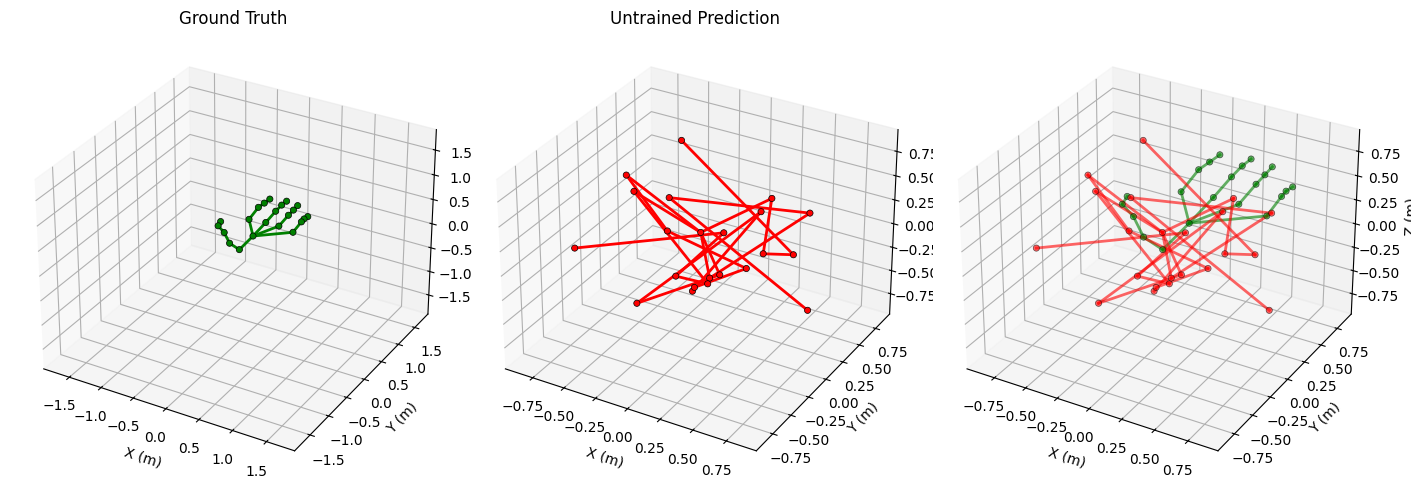

Per-joint error (untrained): mean=1.2625 m, max=2.1167 m


In [6]:
# Helper: bone connections for skeleton visualization
BONES = [
    (0,1),(0,2),(2,3),(3,4),(4,5),
    (1,6),(6,7),(7,8),(8,9),
    (1,10),(10,11),(11,12),(12,13),
    (1,14),(14,15),(15,16),(16,17),
    (1,18),(18,19),(19,20),(20,21)
]

def plot_skeleton_3d(ax, skeleton, title='', color='blue', alpha=1.0):
    """
    Plot a 3D skeleton.
    skeleton: (22, 3) numpy array
    """
    # Plot bones
    for i, j in BONES:
        ax.plot([skeleton[i,0], skeleton[j,0]],
                [skeleton[i,1], skeleton[j,1]],
                [skeleton[i,2], skeleton[j,2]],
                c=color, lw=2, alpha=alpha)
    
    # Plot joints
    ax.scatter(skeleton[:,0], skeleton[:,1], skeleton[:,2],
               c=color, s=20, alpha=alpha, edgecolors='k', linewidths=0.5)
    
    ax.set_xlabel('X (m)')
    ax.set_ylabel('Y (m)')
    ax.set_zlabel('Z (m)')
    ax.set_title(title)
    
    # Equal aspect ratio
    max_range = np.abs(skeleton).max()
    ax.set_xlim([-max_range, max_range])
    ax.set_ylim([-max_range, max_range])
    ax.set_zlim([-max_range, max_range])


# Visualize untrained predictions
model.eval()
depth, skel_gt, label = train_ds[100]

with torch.no_grad():
    depth_batch = depth.unsqueeze(0).to(device)  # (1, 1, T, 64, 64)
    skel_pred = model(depth_batch).cpu().squeeze(0).numpy()  # (22, 3)

skel_gt_np = skel_gt.numpy()

fig = plt.figure(figsize=(14, 5))

ax1 = fig.add_subplot(131, projection='3d')
plot_skeleton_3d(ax1, skel_gt_np, title='Ground Truth', color='green')

ax2 = fig.add_subplot(132, projection='3d')
plot_skeleton_3d(ax2, skel_pred, title='Untrained Prediction', color='red')

ax3 = fig.add_subplot(133, projection='3d')
plot_skeleton_3d(ax3, skel_gt_np, title='Overlay', color='green', alpha=0.6)
plot_skeleton_3d(ax3, skel_pred, title='', color='red', alpha=0.6)

plt.tight_layout()
plt.show()

# Compute error
error = np.linalg.norm(skel_pred - skel_gt_np, axis=1)
print(f'Per-joint error (untrained): mean={error.mean():.4f} m, max={error.max():.4f} m')

---
## 5. Training Loop — Stage 1 <a id='5'></a>

**Loss function:** Weighted SmoothL1 loss with emphasis on palm joints.

**Palm joints** (indices 0, 5, 9, 13, 17): Wrist + 4 MCPs — these are the 5 keypoints used for Branch B position estimation.

In [7]:
# ── Loss function with per-joint weighting ──────────────────────────────────
def weighted_skeleton_loss(pred, target, palm_joints=[0,5,9,13,17], palm_weight=2.0):
    """
    Use MSE instead of SmoothL1 for clearer gradients with normalized data.
    """
    weights = torch.ones(22, device=pred.device)
    weights[palm_joints] = palm_weight
    
    # Per-joint MSE
    diff = (pred - target) ** 2  # (B, 22, 3)
    diff = diff.mean(dim=2)  # (B, 22) — average over (x,y,z)
    
    # Apply weights
    weighted_diff = diff * weights[None, :]
    
    return weighted_diff.mean()


# ── Hyperparameters ─────────────────────────────────────────────────────────
# ══════════════════════════════════════════════════════════════════════════════
# DataLoaders — Windows-compatible (num_workers=0)
# ══════════════════════════════════════════════════════════════════════════════

BATCH_SIZE = 32
NUM_EPOCHS = 30
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
PALM_WEIGHT = 2.0

# Use num_workers=0 on Windows to avoid multiprocessing issues
train_loader = DataLoader(
    train_ds, 
    batch_size=BATCH_SIZE, 
    shuffle=True,
    num_workers=0,  # ← Changed from 2 to 0
    pin_memory=True if torch.cuda.is_available() else False,
)

val_loader = DataLoader(
    val_ds, 
    batch_size=BATCH_SIZE, 
    shuffle=False,
    num_workers=0,  # ← Changed from 2 to 0
    pin_memory=True if torch.cuda.is_available() else False,
)

# Optimizer & Scheduler (unchanged)
from torch.optim.lr_scheduler import LinearLR, SequentialLR

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# Warmup for 3 epochs, then cosine decay
warmup_scheduler = LinearLR(optimizer, start_factor=0.1, total_iters=3)
cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS-3)
scheduler = SequentialLR(optimizer, schedulers=[warmup_scheduler, cosine_scheduler], milestones=[3])

# Training history
history = {
    'train_loss': [],
    'val_loss': [],
    'val_error_mean': [],
    'val_error_palm': [],
}

print(f'Device: {device}')
print(f'Batch size: {BATCH_SIZE}')
print(f'Train batches: {len(train_loader)}')
print(f'Val batches: {len(val_loader)}')
print(f'Epochs: {NUM_EPOCHS}\n')


Device: cuda
Batch size: 32
Train batches: 2123
Val batches: 236
Epochs: 30



In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# Speed test: measure batch loading time
# ══════════════════════════════════════════════════════════════════════════════
import time

print("\nTesting dataloader speed...")
test_loader = DataLoader(train_ds, batch_size=32, shuffle=False, 
                         num_workers=0, pin_memory=False)

start = time.time()
for i, (depth, skel, labels) in enumerate(test_loader):
    if i >= 5:
        break
    print(f"Batch {i+1}: depth={depth.shape}, skel={skel.shape}")

elapsed = time.time() - start
print(f"\nLoaded 5 batches in {elapsed:.2f}s ({elapsed/5:.3f}s per batch)")
print(f"Estimated time per epoch: {(elapsed/5) * len(train_loader) / 60:.1f} minutes")


Testing dataloader speed...
Batch 1: depth=torch.Size([32, 1, 16, 64, 64]), skel=torch.Size([32, 22, 3])
Batch 2: depth=torch.Size([32, 1, 16, 64, 64]), skel=torch.Size([32, 22, 3])
Batch 3: depth=torch.Size([32, 1, 16, 64, 64]), skel=torch.Size([32, 22, 3])
Batch 4: depth=torch.Size([32, 1, 16, 64, 64]), skel=torch.Size([32, 22, 3])
Batch 5: depth=torch.Size([32, 1, 16, 64, 64]), skel=torch.Size([32, 22, 3])

Loaded 5 batches in 0.02s (0.005s per batch)
Estimated time per epoch: 0.2 minutes


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Training Loop with Proper Denormalization
# ══════════════════════════════════════════════════════════════════════════════

best_val_loss = float('inf')
palm_joints = [0, 5, 9, 13, 17]
SCALE_FACTOR = train_ds_full.scale_factor  # Should be 10.0

for epoch in range(NUM_EPOCHS):
    # ── Train ───────────────────────────────────────────────────────────────
    model.train()
    train_loss_accum = 0.0
    num_batches = 0
    
    pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{NUM_EPOCHS} [Train]', 
                 dynamic_ncols=True)
    
    for batch_idx, (depth, skel_gt, labels) in enumerate(pbar):
        depth = depth.to(device, non_blocking=True)
        skel_gt = skel_gt.to(device, non_blocking=True)
        
        skel_pred = model(depth)
        loss = weighted_skeleton_loss(skel_pred, skel_gt, palm_joints, PALM_WEIGHT)
        
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        train_loss_accum += loss.item()
        num_batches += 1
        
        if batch_idx % 10 == 0:
            pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'avg': f'{train_loss_accum/num_batches:.4f}'
            })
    
    train_loss = train_loss_accum / num_batches
    history['train_loss'].append(train_loss)
    
    # ── Validation ──────────────────────────────────────────────────────────
    model.eval()
    val_loss_accum = 0.0
    val_errors = []
    val_errors_palm = []
    
    with torch.no_grad():
        pbar_val = tqdm(val_loader, desc=f'Epoch {epoch+1}/{NUM_EPOCHS} [Val]',
                        dynamic_ncols=True)
        
        for depth, skel_gt, labels in pbar_val:
            depth = depth.to(device, non_blocking=True)
            skel_gt = skel_gt.to(device, non_blocking=True)
            
            skel_pred = model(depth)
            loss = weighted_skeleton_loss(skel_pred, skel_gt, palm_joints, PALM_WEIGHT)
            val_loss_accum += loss.item()
            
            # DENORMALIZE before computing metric (convert back to meters)
            skel_pred_m = skel_pred / SCALE_FACTOR  # Scaled coords → meters
            skel_gt_m = skel_gt / SCALE_FACTOR
            
            # Compute error in METERS
            error = torch.norm(skel_pred_m - skel_gt_m, dim=2)  # (B, 22)
            val_errors.append(error.mean(dim=1).cpu().numpy())
            val_errors_palm.append(error[:, palm_joints].mean(dim=1).cpu().numpy())
    
    val_loss = val_loss_accum / len(val_loader)
    val_error_mean = np.concatenate(val_errors).mean()
    val_error_palm = np.concatenate(val_errors_palm).mean()
    
    history['val_loss'].append(val_loss)
    history['val_error_mean'].append(val_error_mean)
    history['val_error_palm'].append(val_error_palm)
    
    scheduler.step()
    
    print(f'\nEpoch {epoch+1}/{NUM_EPOCHS} Summary:')
    print(f'  Train Loss: {train_loss:.4f}')
    print(f'  Val Loss:   {val_loss:.4f}')
    print(f'  Val Error:  {val_error_mean*100:.2f} cm (all joints), '
          f'{val_error_palm*100:.2f} cm (palm joints)')
    print(f'  LR:         {optimizer.param_groups[0]["lr"]:.6f}')
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'val_error_mean': val_error_mean,
            'val_error_palm': val_error_palm,
            'scale_factor': SCALE_FACTOR,  # Save for later use
        }, PROC_DIR / 'stage1_best.pth')
        print(f'  ✓ Saved best model (val_loss={val_loss:.4f})\n')
    else:
        print()

print('═' * 80)
print('Training complete!')
print(f'Best validation loss: {best_val_loss:.4f}')
print('═' * 80)

Epoch 1/30 [Train]:   0%|          | 0/2123 [00:00<?, ?it/s]

Epoch 1/30 [Val]:   0%|          | 0/236 [00:00<?, ?it/s]


Epoch 1/30 Summary:
  Train Loss: 0.1659
  Val Loss:   0.1510
  Val Error:  4.57 cm (all joints), 5.06 cm (palm joints)
  LR:         0.000400
  ✓ Saved best model (val_loss=0.1510)



Epoch 2/30 [Train]:   0%|          | 0/2123 [00:00<?, ?it/s]

Epoch 2/30 [Val]:   0%|          | 0/236 [00:00<?, ?it/s]

...


Epoch 11/30 Summary:
  Train Loss: 0.1114
  Val Loss:   0.1161
  Val Error:  3.95 cm (all joints), 4.39 cm (palm joints)
  LR:         0.000799
  ✓ Saved best model (val_loss=0.1161)



Epoch 12/30 [Train]:   0%|          | 0/2123 [00:00<?, ?it/s]

Epoch 12/30 [Val]:   0%|          | 0/236 [00:00<?, ?it/s]


Epoch 12/30 Summary:
  Train Loss: 0.1071
  Val Loss:   0.1063
  Val Error:  3.80 cm (all joints), 4.20 cm (palm joints)
  LR:         0.000750
  ✓ Saved best model (val_loss=0.1063)



Epoch 13/30 [Train]:   0%|          | 0/2123 [00:00<?, ?it/s]

---
## 6. Evaluation & Visualization <a id='6'></a>

In [ ]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Loss curves
axes[0].plot(history['train_loss'], label='Train Loss', linewidth=2)
axes[0].plot(history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Error curves (in cm)
axes[1].plot([e*100 for e in history['val_error_mean']], 
             label='All joints', linewidth=2, color='steelblue')
axes[1].plot([e*100 for e in history['val_error_palm']], 
             label='Palm joints (0,5,9,13,17)', linewidth=2, color='orange')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Mean Error (cm)')
axes[1].set_title('Validation: Mean Euclidean Error')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\nFinal metrics:')
print(f'  Best val loss:        {best_val_loss:.4f}')
print(f'  Final val error (all): {history["val_error_mean"][-1]*100:.2f} cm')
print(f'  Final val error (palm): {history["val_error_palm"][-1]*100:.2f} cm')

In [ ]:
# Visualize trained predictions
model.load_state_dict(torch.load(PROC_DIR / 'stage1_best.pth')['model_state_dict'])
model.eval()

# Pick 4 random validation samples
fig = plt.figure(figsize=(16, 10))
sample_indices = [50, 100, 150, 180]

for plot_idx, sample_idx in enumerate(sample_indices):
    depth, skel_gt, label = val_ds[sample_idx]
    
    with torch.no_grad():
        depth_batch = depth.unsqueeze(0).to(device)
        skel_pred = model(depth_batch).cpu().squeeze(0).numpy()
    
    skel_gt_np = skel_gt.numpy()
    
    # Compute error
    error = np.linalg.norm(skel_pred - skel_gt_np, axis=1)
    palm_error = error[palm_joints].mean()
    
    # Plot
    ax = fig.add_subplot(2, 4, plot_idx*2 + 1, projection='3d')
    plot_skeleton_3d(ax, skel_gt_np, title=f'Sample {sample_idx}: GT', color='green')
    
    ax = fig.add_subplot(2, 4, plot_idx*2 + 2, projection='3d')
    plot_skeleton_3d(ax, skel_gt_np, title=f'Pred (palm err: {palm_error*100:.1f} cm)', 
                     color='green', alpha=0.5)
    plot_skeleton_3d(ax, skel_pred, title='', color='red', alpha=0.8)

plt.tight_layout()
plt.show()

---
## 7. Save Pretrained Backbone <a id='7'></a>

Extract and save only the **backbone** (CNN + Transformer), discarding the decoder head.

This backbone will be loaded in **Stages 2-3** for intention classification and position regression.

In [ ]:
# Load best checkpoint
best_ckpt = torch.load(PROC_DIR / 'stage1_best.pth')
model.load_state_dict(best_ckpt['model_state_dict'])

# Extract backbone weights (exclude decoder)
backbone_state = {
    'cnn': model.cnn.state_dict(),
    'spatial_pool': model.spatial_pool.state_dict(),
    'proj': model.proj.state_dict(),
    'pos_enc': model.pos_enc.data,
    'transformer': model.transformer.state_dict(),
}

# Save
backbone_path = PROC_DIR / 'pretrained_depth_backbone.pth'
torch.save({
    'backbone': backbone_state,
    'training_info': {
        'stage': 1,
        'pretraining_objective': 'depth_to_skeleton_reconstruction',
        'epoch': best_ckpt['epoch'],
        'val_loss': best_ckpt['val_loss'],
        'val_error_mean_cm': best_ckpt['val_error_mean'] * 100,
        'val_error_palm_cm': best_ckpt['val_error_palm'] * 100,
        'd_model': 128,
        'nhead': 4,
        'num_layers': 3,
    }
}, backbone_path)

print(f'✓ Saved pretrained backbone to: {backbone_path}')
print(f'\nBackbone components:')
for key in backbone_state.keys():
    print(f'  - {key}')

print(f'\nTraining info:')
for key, val in torch.load(backbone_path)['training_info'].items():
    print(f'  {key}: {val}')

---
## 8. Ablation: Compare vs Gesture Classification <a id='8'></a>

**Optional**: Train a baseline using 14-class gesture classification (the original proposal) to compare pretraining quality.

**Hypothesis**: Reconstruction pretraining should produce better features for Branch B (position regression) because it learns explicit 3D spatial structure, whereas classification only learns discriminative gesture patterns.

**How to test**: After Stage 3, compare the position estimation error when using:
- Backbone pretrained with **reconstruction** (this notebook)
- Backbone pretrained with **classification** (14-class SHREC gestures)
- Backbone trained **from scratch** (no pretraining)

We'll implement the classification baseline in a separate cell for completeness.

In [ ]:
# Classification baseline model (for comparison)
class DepthGestureClassifier(nn.Module):
    """Same backbone as DepthToSkeletonModel, but with classification head."""
    def __init__(self, num_classes=14, d_model=128, nhead=4, num_layers=3, dropout=0.1):
        super().__init__()
        
        # ── Same CNN + Transformer as reconstruction model ────────────────────
        self.cnn = nn.Sequential(
            nn.Conv3d(1, 32, kernel_size=(1,3,3), padding=(0,1,1)),
            nn.BatchNorm3d(32), nn.ReLU(inplace=True), nn.MaxPool3d((1,2,2)),
            nn.Conv3d(32, 64, kernel_size=(1,3,3), padding=(0,1,1)),
            nn.BatchNorm3d(64), nn.ReLU(inplace=True), nn.MaxPool3d((1,2,2)),
            nn.Conv3d(64, 128, kernel_size=(1,3,3), padding=(0,1,1)),
            nn.BatchNorm3d(128), nn.ReLU(inplace=True), nn.MaxPool3d((1,2,2)),
        )
        self.spatial_pool = nn.AdaptiveAvgPool3d((None, 1, 1))
        self.proj = nn.Linear(128, d_model)
        self.pos_enc = nn.Parameter(torch.randn(1, 16, d_model) * 0.02)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model*2,
            dropout=dropout, activation='gelu', batch_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # ── Classification head (14-class SHREC gestures) ──────────────────────
        self.classifier = nn.Sequential(
            nn.Linear(d_model, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )
    
    def forward(self, depth, return_features=False):
        B, _, T, H, W = depth.shape
        x = self.cnn(depth)
        x = self.spatial_pool(x).squeeze(-1).squeeze(-1).permute(0, 2, 1)
        x = self.proj(x) + self.pos_enc[:, :T, :]
        x = self.transformer(x)
        feat = x.mean(dim=1)  # (B, d_model)
        logits = self.classifier(feat)
        
        if return_features:
            return logits, feat
        return logits

print('Classification baseline model defined.')
print('To train: load depth windows + gesture labels, use CrossEntropyLoss.')
print('(Implementation left as exercise — focus on reconstruction for now.)')